In [2]:
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


 **Decision tree classifier**

In [5]:
import numpy as np
import matplotlib.pyplot as plt

import sklearn
from sklearn import tree
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.metrics import roc_auc_score, confusion_matrix
import graphviz

print('sklearn version available is: ', sklearn.__version__)


sklearn version available is:  1.6.1


**On Synthetic Data**

In [6]:

# On Synthetic data:
X, y = make_classification(n_samples = 100, n_features=2,
                                n_redundant=0, n_informative=2,
                                n_clusters_per_class=1, flip_y = 0.1,
                                class_sep = 0.5, random_state=0)

# Split the dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Decision tree classifier
clf = DecisionTreeClassifier(random_state=0)

# Train
clf.fit(X_train, y_train)

# Test
print('Train accuracy on synthetic data: ', clf.score(X_train, y_train))
print('Test accuracy on synthetic data: ', clf.score(X_test, y_test))


Train accuracy on synthetic data:  1.0
Test accuracy on synthetic data:  0.84


**On Real-world Data**

In [7]:
cancer = load_breast_cancer()
X, y = load_breast_cancer(return_X_y=True)
print('Breast cancer data: ', X.shape, y.shape)
print('Unique labels: ', np.unique(y))

# Split the dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)


# Decision tree classifier
clf = DecisionTreeClassifier(random_state=0)

# Train
clf.fit(X_train, y_train)

# Test
print('Train accuracy on breast cancer data: ', clf.score(X_train, y_train))
print('Test accuracy on breast cancer data: ', clf.score(X_test, y_test))
# print('Test accuracy: ', roc_auc_score(y_test, clf.predict(X_test)))

Breast cancer data:  (569, 30) (569,)
Unique labels:  [0 1]
Train accuracy on breast cancer data:  1.0
Test accuracy on breast cancer data:  0.8811188811188811


****

**Plotting tree**

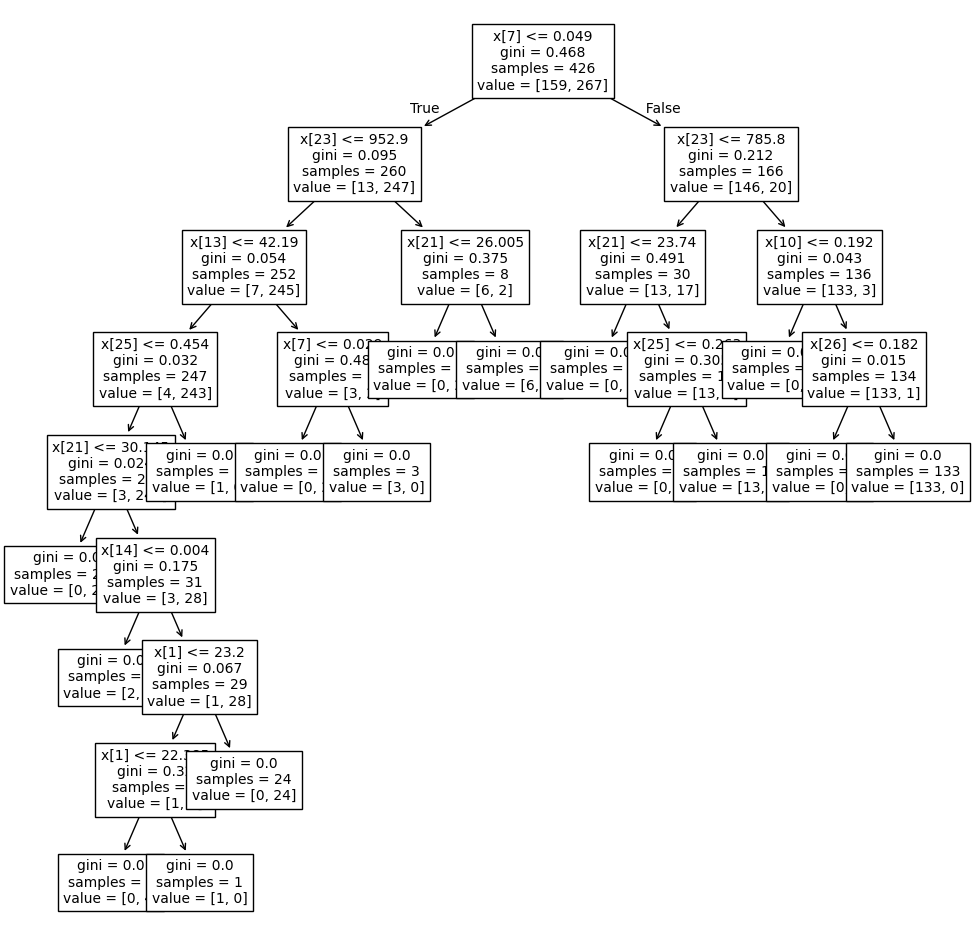

In [8]:
# Using plot_tree
plt.figure(figsize=(12,12))  # set plot size (denoted in inches)
tree.plot_tree(clf, fontsize=10)
plt.show()

In [9]:
print('max_depth: ', clf.tree_.max_depth)

max_depth:  8


In [10]:
# Using graphviz
dot_data = tree.export_graphviz(clf, out_file=None)
graph = graphviz.Source(dot_data)
#graph.render("breast_cancer")  # Saves pdf file
graph

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

**Handling Oveerfitting in Decision tree classifier**

# 1. Pre-pruning (before training the model)

In [11]:
# https://towardsdatascience.com/3-techniques-to-avoid-overfitting-of-decision-trees-1e7d3d985a09

print('--- Pre-pruning (before training the model) -----------------------:')

# Apply GridSearchCV technique to find the best set of hyperparameters for a decision tree model.
param_grid = {
    "max_depth": [3, 5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 7, 10],
    "min_samples_leaf": [1, 2, 5]
}

clf = DecisionTreeClassifier(random_state=0)
grid_cv = GridSearchCV(clf, param_grid, scoring="roc_auc", n_jobs=-1, cv=3).fit(X_train, y_train)

print("Param for GS", grid_cv.best_params_)
print("CV score for GS", grid_cv.best_score_)
print("Train AUC ROC Score for GS: ", roc_auc_score(y_train, grid_cv.predict(X_train)))
print("Test AUC ROC Score for GS: ", roc_auc_score(y_test, grid_cv.predict(X_test)))


--- Pre-pruning (before training the model) -----------------------:
Param for GS {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
CV score for GS 0.9557275104232916
Train AUC ROC Score for GS:  0.9737121051515795
Test AUC ROC Score for GS:  0.9405660377358491


# 2. Post-pruning (after training the model)

--- Post-pruning (after training the model) -----------------------:


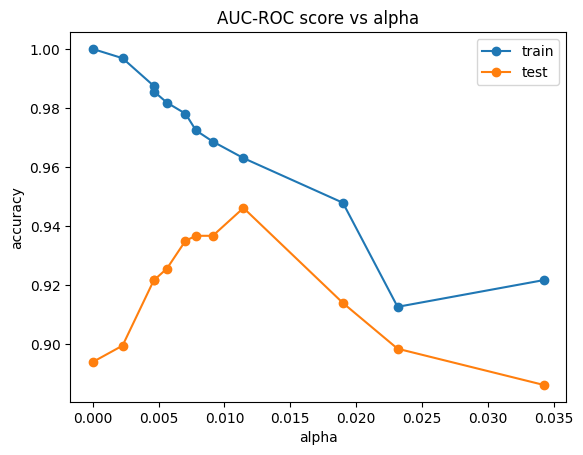

Maximum test score of 0.9461215932914046 is obtained at ccp_alpha of 0.011443661971830986 with training score of 0.9630061479754081.


In [12]:
print('--- Post-pruning (after training the model) -----------------------:')

# Allow a decision tree to grow to its full depth
clf = DecisionTreeClassifier(random_state=0)
clf.fit(X_train, y_train)

# Compute ccp_alpha values
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Train decision tree classifier for each ccp_alpha value
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

# Plot train and test score for each of the above trained model
clfs = clfs[:-1]  # We ignore the last one since, in this case, gives very low train and test score for better plot.
ccp_alphas = ccp_alphas[:-1]

train_scores = [roc_auc_score(y_train, clf.predict(X_train)) for clf in clfs]
test_scores = [roc_auc_score(y_test, clf.predict(X_test)) for clf in clfs]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("AUC-ROC score vs alpha")
ax.plot(ccp_alphas, train_scores, marker='o', label="train")
ax.plot(ccp_alphas, test_scores, marker='o', label="test")
ax.legend()
plt.show()

# Maximum test score
ind_max = np.argmax(test_scores)
test_score_max = test_scores[ind_max]
train_score_at_test_score_max =  train_scores[ind_max]
ccp_alpha_at_test_score_max = ccp_alphas[ind_max]
clf_best = clfs[ind_max]  # This is the best decision tree model after post-pruning

print('Maximum test score of ' + str(test_score_max) + ' is obtained at ccp_alpha of ' + str(ccp_alpha_at_test_score_max)
      + ' with training score of ' + str(train_score_at_test_score_max) + '.')

**Plot Feature Importance**

In [13]:
print(clf_best)
print(clf_best.tree_.max_depth)

DecisionTreeClassifier(ccp_alpha=np.float64(0.011443661971830986),
                       random_state=0)
3


The number of featrues used are:  30


([<matplotlib.axis.YTick at 0x15da77110>,
 [Text(0, 0, 'mean radius'),
  Text(0, 1, 'mean texture'),
  Text(0, 2, 'mean perimeter'),
  Text(0, 3, 'mean area'),
  Text(0, 4, 'mean smoothness'),
  Text(0, 5, 'mean compactness'),
  Text(0, 6, 'mean concavity'),
  Text(0, 7, 'mean concave points'),
  Text(0, 8, 'mean symmetry'),
  Text(0, 9, 'mean fractal dimension'),
  Text(0, 10, 'radius error'),
  Text(0, 11, 'texture error'),
  Text(0, 12, 'perimeter error'),
  Text(0, 13, 'area error'),
  Text(0, 14, 'smoothness error'),
  Text(0, 15, 'compactness error'),
  Text(0, 16, 'concavity error'),
  Text(0, 17, 'concave points error'),
  Text(0, 18, 'symmetry error'),
  Text(0, 19, 'fractal dimension error'),
  Text(0, 20, 'worst radius'),
  Text(0, 21, 'worst texture'),
  Text(0, 22, 'worst perimeter'),
  Text(0, 23, 'worst area'),
  Text(0, 24, 'worst smoothness'),
  Text(0, 25, 'worst compactness'),
  Text(0, 26, 'worst concavity'),
  Text(0, 27, 'worst concave points'),
  Text(0, 28, 'wor

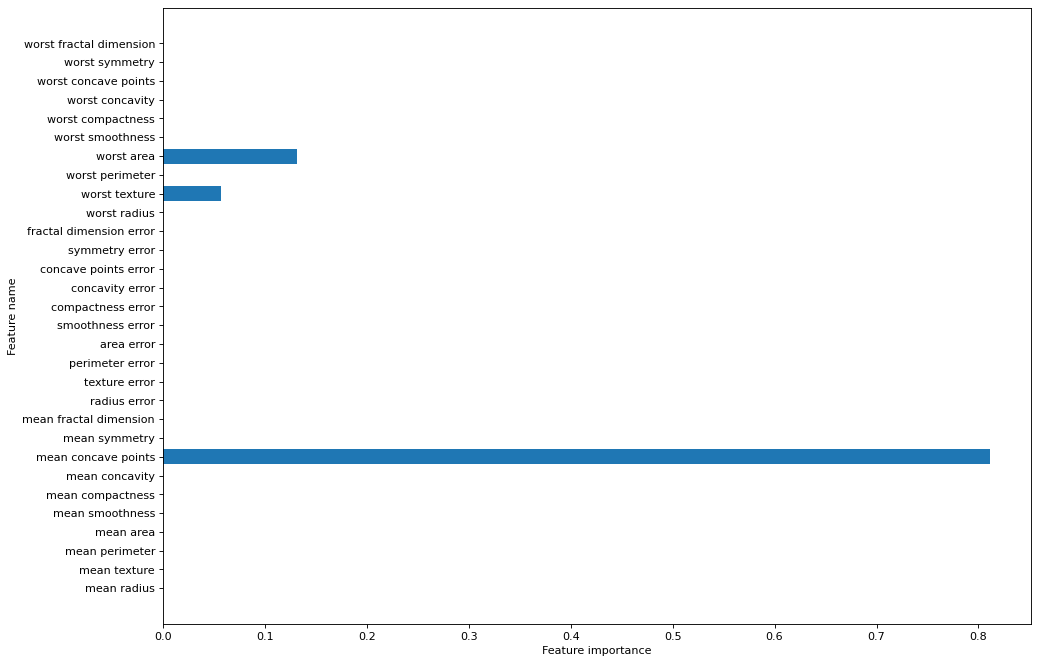

In [14]:
plt.figure(figsize=(14,10),dpi=80)
c_features = len(cancer.feature_names)
print('The number of featrues used are: ', c_features)
plt.barh(range(c_features), clf_best.feature_importances_)
plt.xlabel("Feature importance")
plt.ylabel("Feature name")
plt.yticks(np.arange(c_features), cancer.feature_names)

**Plot Confusion matrix**

In [15]:
conf_matrix = confusion_matrix(y_test, clf_best.predict(X_test))
print('Confusion matrix on test data is: \n', conf_matrix)

Confusion matrix on test data is: 
 [[52  1]
 [ 8 82]]


**Ensemble Learning**

In [16]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Random Forest
rfc = RandomForestClassifier(random_state = 0)
rfc.fit(X_train, y_train)


RandomForestClassifier(random_state=0)

In [17]:
print('Accuracy on training data is ', rfc.score(X_train, y_train))
print('Accuracy on test data is ', rfc.score(X_test, y_test))

Accuracy on training data is  1.0
Accuracy on test data is  0.972027972027972


The number of featrues used are:  30


([<matplotlib.axis.YTick at 0x15dc65090>,
 [Text(0, 0, 'mean radius'),
  Text(0, 1, 'mean texture'),
  Text(0, 2, 'mean perimeter'),
  Text(0, 3, 'mean area'),
  Text(0, 4, 'mean smoothness'),
  Text(0, 5, 'mean compactness'),
  Text(0, 6, 'mean concavity'),
  Text(0, 7, 'mean concave points'),
  Text(0, 8, 'mean symmetry'),
  Text(0, 9, 'mean fractal dimension'),
  Text(0, 10, 'radius error'),
  Text(0, 11, 'texture error'),
  Text(0, 12, 'perimeter error'),
  Text(0, 13, 'area error'),
  Text(0, 14, 'smoothness error'),
  Text(0, 15, 'compactness error'),
  Text(0, 16, 'concavity error'),
  Text(0, 17, 'concave points error'),
  Text(0, 18, 'symmetry error'),
  Text(0, 19, 'fractal dimension error'),
  Text(0, 20, 'worst radius'),
  Text(0, 21, 'worst texture'),
  Text(0, 22, 'worst perimeter'),
  Text(0, 23, 'worst area'),
  Text(0, 24, 'worst smoothness'),
  Text(0, 25, 'worst compactness'),
  Text(0, 26, 'worst concavity'),
  Text(0, 27, 'worst concave points'),
  Text(0, 28, 'wor

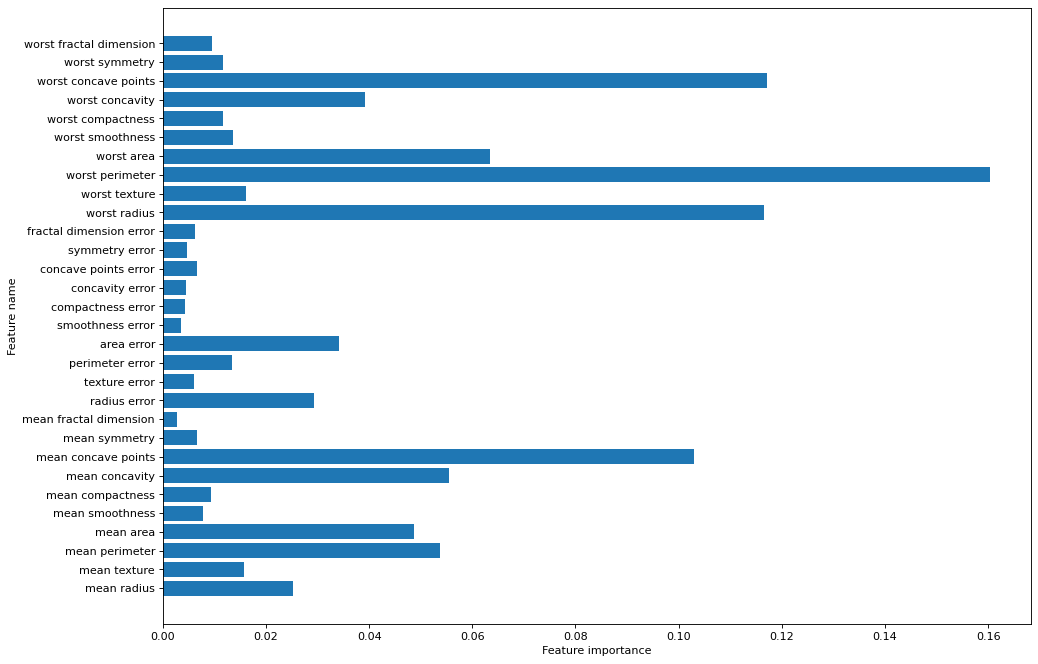

In [18]:
# Plot feature importance using random forest classifieer
plt.figure(figsize=(14,10),dpi=80)
c_features = len(cancer.feature_names)
print('The number of featrues used are: ', c_features)
plt.barh(range(c_features), rfc.feature_importances_)
plt.xlabel("Feature importance")
plt.ylabel("Feature name")
plt.yticks(np.arange(c_features), cancer.feature_names)

In [19]:
# Gradient boosting decision tree
gbc = GradientBoostingClassifier(random_state = 0)
gbc.fit(X_train, y_train)

GradientBoostingClassifier(random_state=0)

In [20]:
print('Accuracy on training data is ', gbc.score(X_train, y_train))
print('Accuracy on test data is ', gbc.score(X_test, y_test))

Accuracy on training data is  1.0
Accuracy on test data is  0.965034965034965


The number of featrues used are:  30


([<matplotlib.axis.YTick at 0x15e044e10>,
 [Text(0, 0, 'mean radius'),
  Text(0, 1, 'mean texture'),
  Text(0, 2, 'mean perimeter'),
  Text(0, 3, 'mean area'),
  Text(0, 4, 'mean smoothness'),
  Text(0, 5, 'mean compactness'),
  Text(0, 6, 'mean concavity'),
  Text(0, 7, 'mean concave points'),
  Text(0, 8, 'mean symmetry'),
  Text(0, 9, 'mean fractal dimension'),
  Text(0, 10, 'radius error'),
  Text(0, 11, 'texture error'),
  Text(0, 12, 'perimeter error'),
  Text(0, 13, 'area error'),
  Text(0, 14, 'smoothness error'),
  Text(0, 15, 'compactness error'),
  Text(0, 16, 'concavity error'),
  Text(0, 17, 'concave points error'),
  Text(0, 18, 'symmetry error'),
  Text(0, 19, 'fractal dimension error'),
  Text(0, 20, 'worst radius'),
  Text(0, 21, 'worst texture'),
  Text(0, 22, 'worst perimeter'),
  Text(0, 23, 'worst area'),
  Text(0, 24, 'worst smoothness'),
  Text(0, 25, 'worst compactness'),
  Text(0, 26, 'worst concavity'),
  Text(0, 27, 'worst concave points'),
  Text(0, 28, 'wor

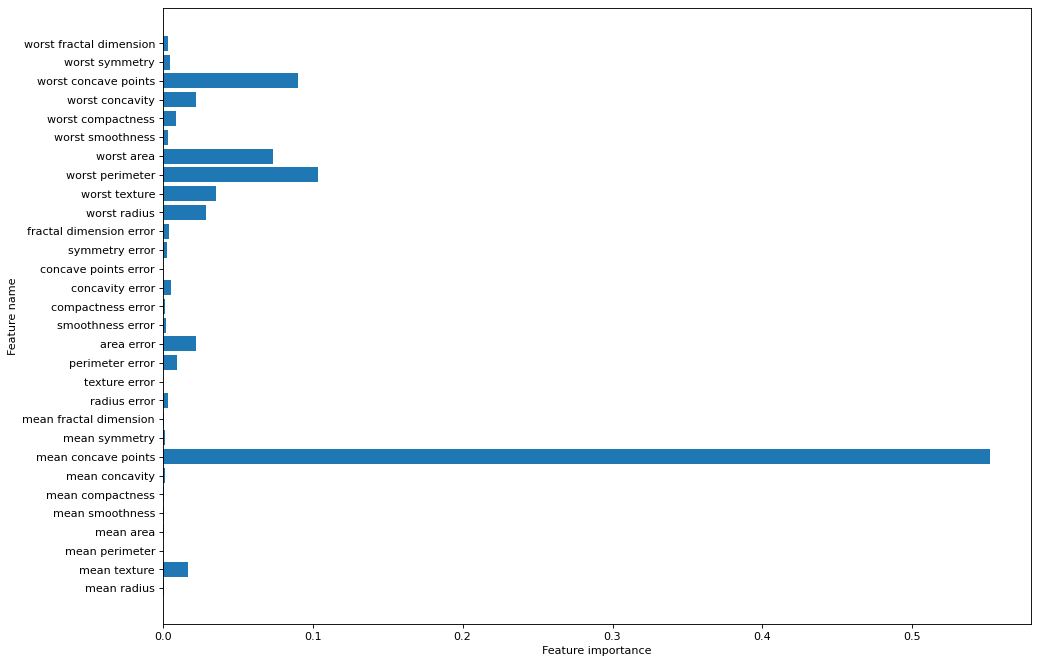

In [21]:
# Plot feature importance using gradient boosting decision tree classifier
plt.figure(figsize=(14,10),dpi=80)
c_features = len(cancer.feature_names)
print('The number of featrues used are: ', c_features)
plt.barh(range(c_features), gbc.feature_importances_)
plt.xlabel("Feature importance")
plt.ylabel("Feature name")
plt.yticks(np.arange(c_features), cancer.feature_names)

In [22]:
# Todo: implement example of stacking - https://scikit-learn.org/stable/modules/ensemble.html
# Stacked generalization is a method for combining estimators to reduce their biases. More precisely, the predictions of each individual estimator are stacked
# together and used as input to a final estimator to compute the prediction. This final estimator is trained through cross-validation.
# The StackingClassifier and StackingRegressor provide such strategies which can be applied to classification and regression problems.
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.neighbors import KNeighborsRegressor
estimators = [('ridge', RidgeCV()),
              ('lasso', LassoCV(random_state=42)),
              ('knr', KNeighborsRegressor(n_neighbors=20,
                                          metric='euclidean'))]  # The estimators parameter corresponds to the list of the estimators which are stacked together
                                                                 # in parallel on the input data. It should be given as a list of names and estimators.

In [23]:
# The final_estimator will use the predictions of the estimators as input. It needs to be a classifier or a regressor when using StackingClassifier or
# StackingRegressor, respectively.
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import StackingRegressor
final_estimator = GradientBoostingRegressor(
    n_estimators=25, subsample=0.5, min_samples_leaf=25, max_features=1,
    random_state=42)
reg = StackingRegressor(
    estimators=estimators,
    final_estimator=final_estimator)

In [24]:
# To train the estimators and final_estimator, the fit method needs to be called on the training data:
from sklearn.datasets import load_diabetes
X, y = load_diabetes(return_X_y=True)  # NOTE: Different dataset is used here.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=42)
reg.fit(X_train, y_train)

StackingRegressor(estimators=[('ridge', RidgeCV()),
                              ('lasso', LassoCV(random_state=42)),
                              ('knr',
                               KNeighborsRegressor(metric='euclidean',
                                                   n_neighbors=20))],
                  final_estimator=GradientBoostingRegressor(max_features=1,
                                                            min_samples_leaf=25,
                                                            n_estimators=25,
                                                            random_state=42,
                                                            subsample=0.5))

In [25]:
# A StackingRegressor and StackingClassifier can be used as any other regressor or classifier, exposing a predict, predict_proba, or decision_function method, e.g.:
y_pred = reg.predict(X_test)
from sklearn.metrics import r2_score
print('R2 score: {:.2f}'.format(r2_score(y_test, y_pred)))

R2 score: 0.53


In [26]:
# Note that it is also possible to get the output of the stacked estimators using the transform method:
reg.transform(X_test[:5])

array([[142.36209608, 138.30724927, 146.1       ],
       [179.700576  , 182.89812552, 151.75      ],
       [139.89817956, 132.46803343, 158.25      ],
       [286.95180286, 292.65695767, 225.4       ],
       [126.88317154, 124.1215975 , 164.65      ]])

In [27]:
# Multiple stacking layers can be achieved by assigning final_estimator to a StackingClassifier or StackingRegressor:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
final_layer_rfr = RandomForestRegressor(
    n_estimators=10, max_features=1, max_leaf_nodes=5,random_state=42)
final_layer_gbr = GradientBoostingRegressor(
    n_estimators=10, max_features=1, max_leaf_nodes=5,random_state=42)
final_layer = StackingRegressor(
    estimators=[('rf', final_layer_rfr),
                ('gbrt', final_layer_gbr)],
    final_estimator=RidgeCV()
    )
multi_layer_regressor = StackingRegressor(
    estimators=[('ridge', RidgeCV()),
                ('lasso', LassoCV(random_state=42)),
                ('knr', KNeighborsRegressor(n_neighbors=20,
                                            metric='euclidean'))],
    final_estimator=final_layer
)
multi_layer_regressor.fit(X_train, y_train)
print('R2 score: {:.2f}'
      .format(multi_layer_regressor.score(X_test, y_test)))

R2 score: 0.53
